# ADOPPTRS — reading the measurements

What the detector achieves, and how to read it. Every figure below is
recomputed from the raw evaluation outputs versioned in `resources/eval/`,
so **this notebook runs straight after a clone**: no model, no imagery, no
GPU. Only `numpy` and `matplotlib`.

The point is not to re-state the numbers of `docs/manual/results.md`, but
to make visible *why* they are what they are — in particular why a single
score never settles which model to use.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath('../python'))
sys.path.insert(0, os.path.abspath('../python/misc'))

from compare_report import parse_output, parse_thresholds, rates
from compare_report import thresholds as decade_labels
from threshold import surface_bias, values as decade_values

EVAL = os.path.abspath('../resources/eval')

plt.rcParams.update({'figure.figsize': (7.5, 4.6), 'axes.grid': True,
                     'grid.alpha': .25, 'font.size': 10})

## Loading

Each file holds two matrices produced by `evaluate.py` — contour-wise and
pixel-wise — with one row per decision threshold. Files measured on the
fine grid carry that grid in their header; the older ones were produced on
the per-decade grid, which is reconstructed.

`rates(..., contour_wise=False)` reproduces `misc/threshold.py -raw`: the
"precision := 0 when nothing is missed" patch is *not* applied, because
these runs scored empty tiles and the artefact it papers over is already
visible in the false positives.

In [2]:
def load(name):
    path = os.path.join(EVAL, name + '.txt')
    arrays = parse_output(path)
    contour, pixel = arrays['contour'], arrays['pixel']

    grid = parse_thresholds(path)
    if grid is None:                      # produced before -thresholds existed
        grid = decade_values()

    p, r, f1 = rates(contour, contour_wise=False)

    return {
        'name': name,
        'threshold': np.asarray(grid, dtype=float),
        'tp': contour[:, 0], 'fp': contour[:, 1], 'fn': contour[:, 2],
        'precision': p, 'recall': r, 'f1': f1,
        'bias': surface_bias(pixel),
    }


def usable(d):
    """Thresholds worth reading.

    At threshold 0 the network keeps every pixel: a single blob covers the
    tile and catches every target, so recall is 1 and F1 looks excellent
    while the surface bias reaches 76. At threshold 1 nothing is kept.
    Both ends are artefacts, and misc/threshold.py still reports the first
    as an optimum -- hence this filter.
    """
    return (d['threshold'] > 0) & (d['threshold'] < 1) & (d['tp'] > 0)


FINE = {
    'production': load('multiunet_liege_030_liege_fin'),
    'BDAPPV chain': load('multiunet_bdwl_040_liege_fin'),
    'hue jitter': load('multiunet_hue_030_liege_fin'),
    'production + opening': load('multiunet_liege_030_liege_ouverture_fin'),
}

for label, d in FINE.items():
    print(f'{label:22s} {usable(d).sum():2d} usable thresholds')

production             13 usable thresholds
BDAPPV chain           13 usable thresholds
hue jitter             13 usable thresholds
production + opening   13 usable thresholds


## Where each model peaks

The optimum is read over usable thresholds only.

In [3]:
def best(d):
    m = usable(d)
    i = np.where(m)[0][np.argmax(d['f1'][m])]
    return i


print(f"{'model':22s} {'thr':>8s} {'prec':>7s} {'recall':>7s} {'F1':>7s} {'bias':>7s}")
print('-' * 62)
for label, d in FINE.items():
    i = best(d)
    print(f"{label:22s} {d['threshold'][i]:8.1e} {d['precision'][i]:7.3f} "
          f"{d['recall'][i]:7.3f} {d['f1'][i]:7.4f} {d['bias'][i]:7.3f}")

model                       thr    prec  recall      F1    bias
--------------------------------------------------------------
production              5.0e-05   0.863   0.819  0.8401   0.944
BDAPPV chain            7.0e-05   0.789   0.907  0.8439   0.838
hue jitter              3.0e-05   0.910   0.804  0.8538   0.816
production + opening    2.0e-04   0.928   0.752  0.8306   0.909


Three observations, none of which a single score would reveal.

**The best F1 belongs to the hue-jitter model**, which is nonetheless the
worst choice here — its surface bias is the lowest, and the deliverable is
a surface converted to kWp, not a count of installations.

**The BDAPPV chain trades precision for recall**, finding around 91 % of
panels where the production model finds 82 %.

**Morphological opening costs more than it saves**, on every column at
once.

## Precision against recall

The curve, rather than a point, is what separates the models. Markers show
each model's F1 optimum.

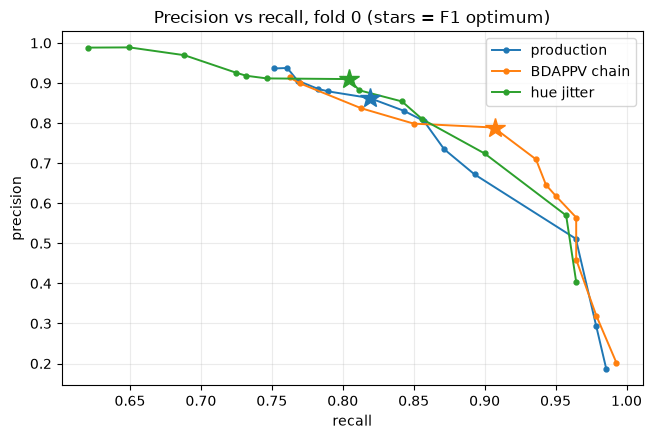

In [4]:
fig, ax = plt.subplots()

for label, d in FINE.items():
    if label == 'production + opening':
        continue
    m = usable(d)
    ax.plot(d['recall'][m], d['precision'][m], 'o-', ms=3.5, lw=1.4, label=label)
    i = best(d)
    ax.plot(d['recall'][i], d['precision'][i], '*', ms=15,
            color=ax.lines[-1].get_color(), zorder=5)

ax.set_xlabel('recall'); ax.set_ylabel('precision')
ax.set_title('Precision vs recall, fold 0 (stars = F1 optimum)')
ax.legend(); plt.show()

Read at **equal recall**, not at equal threshold — thresholds are not
comparable between models, since each network spreads its probabilities
differently.

Around 0.90 recall the BDAPPV chain holds ~0.79 precision where the
production model collapses to ~0.67. That is the comparison that matters,
and it is invisible in any table of optima.

## What actually reaches the capacity estimate

Only the panels that are found contribute, and they are drawn slightly too
small. The product `recall × surface bias` approximates the share of real
surface captured — the quantity the whole project exists to produce.

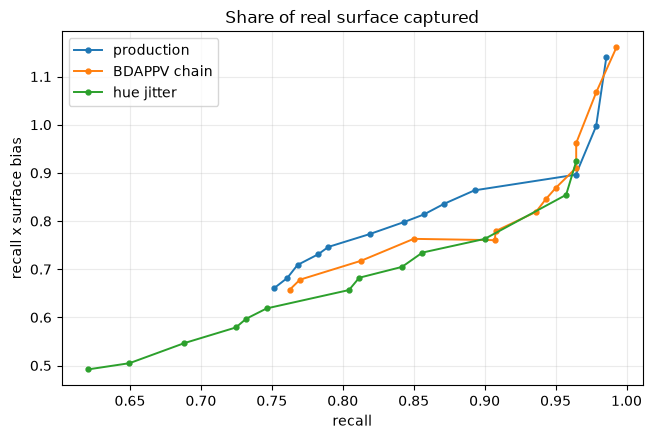

production             at F1 optimum: 0.773
BDAPPV chain           at F1 optimum: 0.760
hue jitter             at F1 optimum: 0.657


In [5]:
fig, ax = plt.subplots()

for label, d in FINE.items():
    if label == 'production + opening':
        continue
    m = usable(d)
    ax.plot(d['recall'][m], d['recall'][m] * d['bias'][m], 'o-', ms=3.5, lw=1.4,
            label=label)

ax.set_xlabel('recall'); ax.set_ylabel('recall x surface bias')
ax.set_title('Share of real surface captured')
ax.legend(); plt.show()

for label, d in FINE.items():
    if label == 'production + opening':
        continue
    i = best(d)
    print(f"{label:22s} at F1 optimum: {d['recall'][i] * d['bias'][i]:.3f}")

The models that looked clearly separated on F1 land within a few percent
of each other here, by opposite routes: one finds fewer installations and
measures them well, the other finds many more and shrinks them.

An approximation, and worth stating: it assumes missed panels average the
same size as found ones, and it ignores the surface of false positives.
The ordering is meaningful, the third decimal is not.

## Why the coarse grid misled us

The original threshold grid tested one value per decade. Both models below
are the *same networks* as above — only the sampling of thresholds
differs.

production     per-decade  best F1 0.8340 at 1.0e-03
production     fine        best F1 0.8401 at 5.0e-05
BDAPPV chain   per-decade  best F1 0.8314 at 1.0e-03
BDAPPV chain   fine        best F1 0.8439 at 7.0e-05


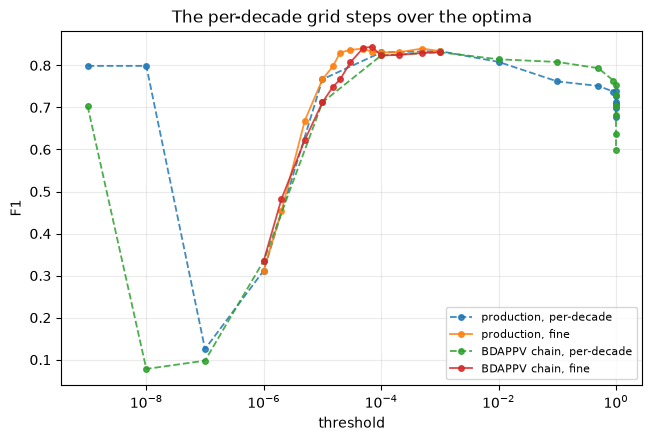

In [6]:
pairs = [
    ('production', 'multiunet_liege_030_liege', 'multiunet_liege_030_liege_fin'),
    ('BDAPPV chain', 'multiunet_bdwl_040_liege', 'multiunet_bdwl_040_liege_fin'),
]

fig, ax = plt.subplots()

for label, coarse_name, fine_name in pairs:
    for style, name in (('o--', coarse_name), ('o-', fine_name)):
        d = load(name)
        m = usable(d)
        grid = 'per-decade' if style == 'o--' else 'fine'
        ax.plot(d['threshold'][m], d['f1'][m], style, ms=4, lw=1.3, alpha=.85,
                label=f'{label}, {grid}')
        i = best(d)
        print(f'{label:14s} {grid:11s} best F1 {d["f1"][i]:.4f} at {d["threshold"][i]:.1e}')

ax.set_xscale('log'); ax.set_xlabel('threshold'); ax.set_ylabel('F1')
ax.set_title('The per-decade grid steps over the optima')
ax.legend(fontsize=8); plt.show()

On the coarse grid the production model reads 0.834 and the BDAPPV chain
0.831 — close enough to conclude that BDAPPV brings nothing, which is
exactly what was concluded on 2026-08-11. On the fine grid the ordering
**reverses**: 0.840 against 0.844, and the recall gap is far wider than
the F1 gap suggests.

Between 1e-5 and 1e-4 the production model's false positives go from 14 to
61. An optimum can hide anywhere in a gap that wide, which is why any
model comparison predating 2026-08-12 should be treated as non-conclusive.

## Takeaways

- Compare models **at equal recall**, never at equal threshold.
- Recalibrate the threshold for **every** model, on a fine grid.
- F1 ranks detection; it does not rank usefulness. Here the surface bias
  decides, because the deliverable is a surface.
- Discard degenerate thresholds before reading any optimum.

Full protocol and figures: `docs/manual/results.md`. Raw measurements and
their provenance: `resources/eval/README.md`.